# Improved Pipeline: Leakage-Free Evaluation, Tuning, Confusion Matrix, Ensemble

The other notebooks in this folder (`randomforest.ipynb`, `xgb.ipynb`, `NN.ipynb`, `stack.ipynb`) all keep the
`subject` column in the feature matrix and evaluate with a random 70/30 split. Since `to_predict.csv` contains
**entirely different subjects** than `measures.csv`, that setup lets the models partly learn *who* is moving
rather than *what* activity it is, which inflates the reported accuracy.

This notebook redoes the evaluation properly:

1. Demonstrate the leakage effect directly (naive vs. honest accuracy on the same model).
2. Tune Random Forest, XGBoost, and an MLP with subject-grouped cross-validation (`StratifiedGroupKFold`,
   grouping by `subject` so no person appears in both the training and validation fold).
3. Look at the confusion matrix to see which activities actually get confused.
4. Combine the tuned models into a soft-voting ensemble.
5. Fit the final ensemble on all of `measures.csv` and predict `to_predict.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedGroupKFold, RandomizedSearchCV, cross_val_score,
    cross_val_predict, train_test_split,
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, cohen_kappa_score,
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_SPLITS = 5
N_ITER = 15


## 1. Load data

Same `edited2_measures.csv` the other notebooks use (duplicate columns already renamed, values already floats).

In [2]:
df = pd.read_csv('../edited2_measures.csv', delimiter=';')
print('shape:', df.shape)

X = df.drop(columns=['activity', 'subject'])
y = df['activity']
groups = df['subject']

print('subjects:', groups.nunique())
print(y.value_counts())


shape: (7352, 563)
subjects: 21
activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


## 2. Why the earlier accuracy numbers were optimistic

Same model (`RandomForestClassifier`, otherwise default-ish params), two setups:

- **Naive**: `subject` left in as a feature, random 70/30 split (what `randomforest.ipynb` etc. do).
- **Honest**: `subject` excluded from the features, 5-fold `StratifiedGroupKFold` so a subject's rows never
  appear in both train and validation for the same fold.


In [3]:
# Naive: subject kept as a feature, random split
X_naive = df.drop(columns=['activity'])
X_train, X_test, y_train, y_test = train_test_split(
    X_naive, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
rf_naive = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_naive.fit(X_train, y_train)
naive_acc = accuracy_score(y_test, rf_naive.predict(X_test))
print(f'Naive (subject as feature, random split) RF accuracy: {naive_acc:.4f}')

imp = pd.Series(rf_naive.feature_importances_, index=X_naive.columns).sort_values(ascending=False)
subject_rank = imp.index.get_loc('subject') + 1
print(f"'subject' feature-importance rank: {subject_rank} / {len(imp)} (importance={imp['subject']:.4f})")


Naive (subject as feature, random split) RF accuracy: 0.9841
'subject' feature-importance rank: 207 / 562 (importance=0.0007)


In [4]:
# Honest: subject excluded, subject-grouped 5-fold CV
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

rf_honest = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
honest_scores = cross_val_score(rf_honest, X, y, groups=groups, cv=sgkf, scoring='accuracy', n_jobs=1)
print(f'Honest (no subject feature, grouped CV) RF accuracy: {honest_scores.mean():.4f} +/- {honest_scores.std():.4f}')
print('fold scores:', np.round(honest_scores, 4))

leakage_gap = naive_acc - honest_scores.mean()
print(f'\nGap caused by subject leakage: {leakage_gap:.4f} ({leakage_gap*100:.2f} percentage points)')


Honest (no subject feature, grouped CV) RF accuracy: 0.9070 +/- 0.0493
fold scores: [0.837  0.9382 0.8861 0.8917 0.9819]

Gap caused by subject leakage: 0.0772 (7.72 percentage points)


## 3. Label encoding

XGBoost's sklearn wrapper requires integer class labels, so we encode once and reuse the same encoded target for every model (keeps RF/XGB/MLP directly comparable and lets them share one `VotingClassifier`).

In [5]:
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))


{'LAYING': 0, 'SITTING': 1, 'STANDING': 2, 'WALKING': 3, 'WALKING_DOWNSTAIRS': 4, 'WALKING_UPSTAIRS': 5}


## 4. Hyperparameter tuning with subject-grouped cross-validation

`RandomizedSearchCV` with `cv=StratifiedGroupKFold(...)` and `groups=subject` passed to `.fit()` — every
candidate parameter set is scored the same honest way as section 2.


In [6]:
rf_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 15, 25, 40],
    'max_features': ['sqrt', 'log2', 0.3],
    'min_samples_leaf': [1, 2, 4],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    rf_param_dist, n_iter=N_ITER, cv=sgkf, scoring='accuracy',
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X, y_enc, groups=groups)
print('Best RF params:', rf_search.best_params_)
print(f'Best RF grouped-CV accuracy: {rf_search.best_score_:.4f}')


Best RF params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best RF grouped-CV accuracy: 0.9235


In [7]:
xgb_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=1, eval_metric='mlogloss'),
    xgb_param_dist, n_iter=N_ITER, cv=sgkf, scoring='accuracy',
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X, y_enc, groups=groups)
print('Best XGB params:', xgb_search.best_params_)
print(f'Best XGB grouped-CV accuracy: {xgb_search.best_score_:.4f}')


Best XGB params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best XGB grouped-CV accuracy: 0.9414


In [8]:
mlp_param_dist = {
    'hidden_layer_sizes': [(100,), (100, 100), (150, 100), (200,)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.005, 0.01],
}
mlp_search = RandomizedSearchCV(
    MLPClassifier(max_iter=300, random_state=RANDOM_STATE),
    mlp_param_dist, n_iter=N_ITER, cv=sgkf, scoring='accuracy',
    random_state=RANDOM_STATE, n_jobs=-1,
)
mlp_search.fit(X, y_enc, groups=groups)
print('Best MLP params:', mlp_search.best_params_)
print(f'Best MLP grouped-CV accuracy: {mlp_search.best_score_:.4f}')


Best MLP params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (100,), 'alpha': 0.0001}
Best MLP grouped-CV accuracy: 0.9374


In [9]:
tuned_results = pd.DataFrame({
    'model': ['Random Forest (untuned baseline)', 'Random Forest (tuned)', 'XGBoost (tuned)', 'MLP (tuned)'],
    'honest_grouped_cv_accuracy': [
        honest_scores.mean(), rf_search.best_score_, xgb_search.best_score_, mlp_search.best_score_,
    ],
}).sort_values('honest_grouped_cv_accuracy', ascending=False).reset_index(drop=True)
tuned_results


,model,honest_grouped_cv_accuracy
0,XGBoost (tuned),0.941390
1,MLP (tuned),0.937370
2,Random Forest (tuned),0.923523
3,Random Forest (untuned baseline),0.906978


## 5. Ensemble: soft-voting over the tuned models

Combine the three tuned models with soft voting (averaged predicted probabilities). Evaluated with
`cross_val_predict` under the same grouped CV splitter, so the resulting predictions are genuinely
out-of-fold for every row — this also gives us the confusion matrix for free.


In [10]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_search.best_estimator_),
        ('xgb', xgb_search.best_estimator_),
        ('mlp', mlp_search.best_estimator_),
    ],
    voting='soft',
)

oof_preds_enc = cross_val_predict(voting_clf, X, y_enc, groups=groups, cv=sgkf, n_jobs=1)
oof_preds = label_encoder.inverse_transform(oof_preds_enc)

ensemble_acc = accuracy_score(y, oof_preds)
ensemble_kappa = cohen_kappa_score(y, oof_preds)
print(f'Ensemble honest grouped-CV accuracy: {ensemble_acc:.4f}')
print(f'Ensemble honest grouped-CV Cohen\'s kappa: {ensemble_kappa:.4f}')
print()
print(classification_report(y, oof_preds))


Ensemble honest grouped-CV accuracy: 0.9470
Ensemble honest grouped-CV Cohen's kappa: 0.9362

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00      1407
           SITTING       0.92      0.90      0.91      1286
          STANDING       0.91      0.93      0.92      1374
           WALKING       0.98      0.94      0.96      1226
WALKING_DOWNSTAIRS       0.96      0.94      0.95       986
  WALKING_UPSTAIRS       0.90      0.97      0.94      1073

          accuracy                           0.95      7352
         macro avg       0.95      0.95      0.95      7352
      weighted avg       0.95      0.95      0.95      7352



## 6. Confusion matrix — which activities are actually confused?

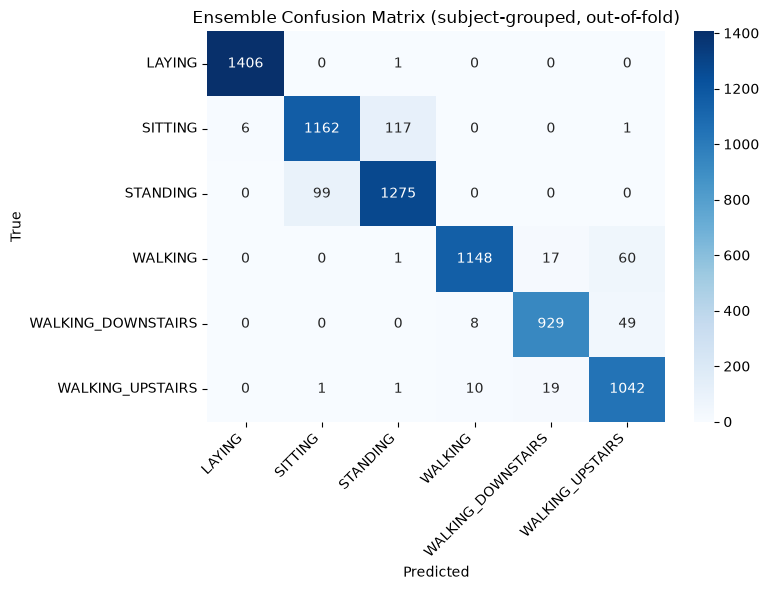

In [11]:
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y, oof_preds, labels=labels_sorted)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Ensemble Confusion Matrix (subject-grouped, out-of-fold)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_ensemble_grouped_cv.png', dpi=150)
plt.show()


In [12]:
# Find the most confused off-diagonal (true, predicted) pair
cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)
off_diag_arr = cm_df.to_numpy(copy=True)
np.fill_diagonal(off_diag_arr, 0)
off_diag = pd.DataFrame(off_diag_arr, index=labels_sorted, columns=labels_sorted)
max_confusion = off_diag.stack().sort_values(ascending=False)
print('Top confused (true -> predicted) pairs:')
print(max_confusion.head(5))


Top confused (true -> predicted) pairs:
SITTING             STANDING              117
STANDING            SITTING                99
WALKING             WALKING_UPSTAIRS       60
WALKING_DOWNSTAIRS  WALKING_UPSTAIRS       49
WALKING_UPSTAIRS    WALKING_DOWNSTAIRS     19
dtype: int64


## 7. Final model: fit on all of `measures.csv`, predict `to_predict.csv`

Fresh clones of the tuned estimators, fit on the full labeled dataset (no held-out fold this time — the
grouped CV above already gave us an honest accuracy estimate), then applied to the unseen subjects in
`to_predict.csv`.


In [13]:
from sklearn.base import clone

final_voting = VotingClassifier(
    estimators=[
        ('rf', clone(rf_search.best_estimator_)),
        ('xgb', clone(xgb_search.best_estimator_)),
        ('mlp', clone(mlp_search.best_estimator_)),
    ],
    voting='soft',
)
final_voting.fit(X, y_enc)

to_predict_df = pd.read_csv('../edited2_to_predict.csv', delimiter=';')
X_new = to_predict_df.drop(columns=['subject'])[X.columns]

pred_enc = final_voting.predict(X_new)
pred_labels = label_encoder.inverse_transform(pred_enc)

output_df = to_predict_df.copy()
output_df['activity'] = pred_labels
output_df.to_csv('../Predictions/ensemble_predictions_grouped_cv.csv', sep=';', index=False)
print('Saved predictions to ../Predictions/ensemble_predictions_grouped_cv.csv')
print(output_df['activity'].value_counts())


Saved predictions to ../Predictions/ensemble_predictions_grouped_cv.csv
activity
STANDING              550
LAYING                537
WALKING               522
SITTING               471
WALKING_UPSTAIRS      466
WALKING_DOWNSTAIRS    401
Name: count, dtype: int64


In [14]:
final_results = pd.concat([
    tuned_results,
    pd.DataFrame({'model': ['Ensemble (RF+XGB+MLP, soft voting)'], 'honest_grouped_cv_accuracy': [ensemble_acc]}),
], ignore_index=True).sort_values('honest_grouped_cv_accuracy', ascending=False).reset_index(drop=True)
final_results.to_csv('../Predictions/model_comparison_honest_cv.csv', sep=';', index=False)
final_results


,model,honest_grouped_cv_accuracy
0,"Ensemble (RF+XGB+MLP, soft voting)",0.946953
1,XGBoost (tuned),0.941390
2,MLP (tuned),0.937370
3,Random Forest (tuned),0.923523
4,Random Forest (untuned baseline),0.906978


## Summary

In [15]:
top_pair = max_confusion.index[0]
print(
    f"Naive (leaky) accuracy: {naive_acc:.4f}  vs.  honest grouped-CV accuracy: {honest_scores.mean():.4f}"
    f"  ->  leakage inflated accuracy by {leakage_gap*100:.2f} percentage points.\n"
    f"Best single tuned model: {tuned_results.iloc[0]['model']} at {tuned_results.iloc[0]['honest_grouped_cv_accuracy']:.4f} honest grouped-CV accuracy.\n"
    f"Ensemble (RF+XGB+MLP, soft voting): {ensemble_acc:.4f} accuracy, {ensemble_kappa:.4f} kappa.\n"
    f"Most confused pair: true {top_pair[0]} predicted as {top_pair[1]} ({int(max_confusion.iloc[0])} cases).\n"
    f"Final predictions for to_predict.csv written to ../Predictions/ensemble_predictions_grouped_cv.csv"
)


Naive (leaky) accuracy: 0.9841  vs.  honest grouped-CV accuracy: 0.9070  ->  leakage inflated accuracy by 7.72 percentage points.
Best single tuned model: XGBoost (tuned) at 0.9414 honest grouped-CV accuracy.
Ensemble (RF+XGB+MLP, soft voting): 0.9470 accuracy, 0.9362 kappa.
Most confused pair: true SITTING predicted as STANDING (117 cases).
Final predictions for to_predict.csv written to ../Predictions/ensemble_predictions_grouped_cv.csv
